<div align="center">

# Classification multi-class FOCH

**Fine-tuning d'un modèle haute-gamme avec les données de l'Hôpital FOCH**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances et les chemins d'accès aux données et aux artefacts. Conformément à une démarche expérimentale rigoureuse, nous construisons d'abord un **modèle de référence (*baseline*) robuste** — *sans* augmentation de données — afin de disposer d'un point de comparaison fiable pour les expériences ultérieures.

**Classes retenues pour le baseline :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` est **exclue** de ce baseline (support insuffisant, n ≈ 26), et aucune technique d'augmentation n'est appliquée à ce stade.

> 💡 **Rappel architecture** — Le backbone est un **WavLM-Large** local. Les poids entraînés et les métriques sont sauvegardés respectivement dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
# Métadonnées patients FOCH — colonnes : Last_Name, File_Name, VSL, patient_id
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
# Voyelles tenues segmentées — cohorte pathologique FOCH
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
# Base Saarbruecken (SVD) — sujets sains (groupe contrôle)
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Backbone et artefacts de sortie ──────────────────────────────────────────
MODEL_DIR   = r'C:/Users/AdminIA/Documents/models/wavlm-large'          # backbone WavLM-Large local
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'       # poids entraînés
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'      # métriques, matrices, graphes
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = 'wavlm_large_baseline'   # préfixe commun des fichiers de sortie

# ── Définition des classes du modèle de référence (baseline) ─────────────────
# La classe 'Cancer' est volontairement EXCLUE (support insuffisant, n ≈ 26)
# et aucune augmentation de données n'est appliquée à ce stade.
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]   # ordre canonique des indices
NUM_LABELS         = len(CLASSES)

# Sous-échantillonnage du groupe contrôle : on ramène 'Healthy' à ~N_HEALTHY
# enregistrements pour obtenir un problème de classification représentatif
# (sinon une accuracy élevée ne ferait que refléter la classe majoritaire saine).
N_HEALTHY          = 100

# ── Hyperparamètres audio & entraînement (WavLM-Large) ───────────────────────
TARGET_SR    = 16000     # WavLM attend un échantillonnage à 16 kHz
MAX_LEN_S    = 4.0       # fenêtre audio (s) — voyelle tenue ; padding / troncature
BATCH_SIZE   = 4         # adapté à 8 Go de VRAM pour un modèle de 316 M de paramètres
ACCUM_STEPS  = 4         # accumulation de gradient → batch effectif = 4 × 4 = 16
EPOCHS       = 30
LR           = 1e-5      # taux d'apprentissage conseillé pour WavLM-Large (petit jeu médical)
WEIGHT_DECAY = 0.01
PATIENCE     = 6         # arrêt anticipé (early stopping)
FREEZE_FE    = True      # gèle l'extracteur convolutif (front-end CNN)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Configuration chargée.')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Backbone        : {MODEL_DIR}')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Backbone        : C:/Users/AdminIA/Documents/models/wavlm-large
  Device          : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  329 lignes
Lignes pathologiques retenues :  217  (PR / LMB / fuite glottique)
Après déduplication patient    :  146  (71 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 48
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 246 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 48
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` PyTorch

Le `Dataset` encapsule l'intégralité de la chaîne de prétraitement audio, appliquée **paresseusement** (à la volée) pour chaque enregistrement :

1. **Chargement** du fichier `.wav` via `torchaudio` ;
2. **Conversion mono** (moyenne des canaux) si nécessaire ;
3. **Ré-échantillonnage** à 16 kHz (fréquence attendue par WavLM) ;
4. **Extraction de features** via le `Wav2Vec2FeatureExtractor` (normalisation + *padding*/troncature à `MAX_LEN_S`).

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie un tenseur nul de secours en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM et Dataset PyTorch
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor chargé : {type(processor).__name__}')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle, le convertit en mono, le ré-échantillonne
    à 16 kHz, puis applique l'extracteur de features WavLM.
    Renvoie un couple (input_values, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len_s=MAX_LEN_S):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = int(target_sr * max_len_s)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave_np = waveform.squeeze().numpy()
            out = self.processor(
                wave_np,
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            tensor = out.input_values.squeeze(0)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            tensor = torch.zeros(self.max_len)
        return tensor, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {int(TARGET_SR * MAX_LEN_S)} échantillons à {TARGET_SR} Hz')

✓ Processor chargé : Wav2Vec2FeatureExtractor
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz


## 5. Découpage train / validation (stratifié et groupé par patient)

Le découpage utilise `StratifiedGroupKFold`, qui combine deux garanties indispensables en contexte clinique :

- **Stratification** — la proportion de chaque classe est préservée dans les deux sous-ensembles, ce qui est critique compte tenu du déséquilibre ;
- **Groupement par patient** (`Last_Name`) — aucun patient ne peut se retrouver simultanément en entraînement et en validation, évitant toute **fuite d'information** qui surestimerait artificiellement les performances.

On retient le premier pli (≈ 80 / 20). Une assertion vérifie *a posteriori* l'absence de patient commun aux deux sous-ensembles.

> 💡 La déduplication (Cellule 2) garantit déjà un enregistrement unique par patient FOCH ; le groupement reste néanmoins appliqué par sécurité et pour préparer les scénarios multi-enregistrements futurs.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Découpage train/validation (stratifié + groupé par patient)
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedGroupKFold

# Premier pli ≈ 80/20, stratifié par classe et groupé par patient (Last_Name).
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df, df['label'], groups=df['Last_Name']))
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

# Vérification stricte de l'absence de fuite patient entre les sous-ensembles.
fuite = set(train_df['Last_Name']) & set(val_df['Last_Name'])
assert not fuite, f'Fuite patient détectée : {sorted(fuite)}'

print(f'Train : {len(train_df)} enregistrements | Val : {len(val_df)} enregistrements')
print('\nRépartition train :')
print(train_df['label_str'].value_counts().reindex(CLASSES).to_string())
print('\nRépartition val :')
print(val_df['label_str'].value_counts().reindex(CLASSES).to_string())

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_ds = FochVowelDataset(train_df, processor)
val_ds   = FochVowelDataset(val_df,   processor)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# Test de cohérence sur le premier batch.
xb, yb = next(iter(train_loader))
print(f'\nForme du batch : {tuple(xb.shape)} | labels : {yb.tolist()}')

Train : 197 enregistrements | Val : 49 enregistrements

Répartition train :
label_str
PR                 58
LMB                38
fuite glottique    21
Healthy            80

Répartition val :
label_str
PR                 14
LMB                10
fuite glottique     5
Healthy            20

Forme du batch : (4, 64000) | labels : [1, 1, 0, 3]


## 6. Initialisation du modèle WavLM-Large

On charge le backbone **WavLM-Large** local et l'on remplace sa tête de classification par une couche neuve dimensionnée pour `NUM_LABELS = 4` sorties. Les `label2id` / `id2label` sont injectés afin que le modèle restitue directement les libellés cliniques.

**Stratégie de transfert (baseline) :** l'extracteur convolutif (front-end CNN) est **gelé** — il encode des caractéristiques acoustiques bas-niveau génériques et transférables. Seuls le transformer et la tête de classification sont entraînés, ce qui réduit le risque de sur-apprentissage sur un petit jeu de données médical.

> ⚠️ L'avertissement HuggingFace concernant les poids non initialisés (`classifier`, `projector`) est **attendu** : il s'agit précisément de la nouvelle tête à entraîner.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Initialisation du modèle WavLM-Large
# ═══════════════════════════════════════════════════════════════════════════
from transformers import WavLMForSequenceClassification

# Tête de classification ré-initialisée pour NUM_LABELS classes.
model = WavLMForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=NUM_LABELS,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

# Gel de l'extracteur convolutif (front-end CNN) : seuls le transformer et la
# tête de classification restent entraînables.
if FREEZE_FE:
    for p in model.wavlm.feature_extractor.parameters():
        p.requires_grad = False
    print('✓ Extracteur de features (CNN) gelé')

model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres totaux       : {total:,}')
print(f'Paramètres entraînables : {trainable:,}  ({100 * trainable / total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: C:/Users/AdminIA/Documents/models/wavlm-large
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.weight  | MISSING | 
classifier.weight | MISSING | 
projector.bias    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Extracteur de features (CNN) gelé
Paramètres totaux       : 315,716,548
Paramètres entraînables : 311,509,956  (98.7 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']


## 7. Boucle d'entraînement (AMP, *early stopping*)

Cette boucle met en œuvre les choix arrêtés pour le baseline :

- **Jeu équilibré par sous-échantillonnage** — le groupe contrôle a été ramené à ~100 enregistrements (Cellule 2), de sorte que les quatre classes ont des effectifs comparables. La perte `CrossEntropyLoss` est donc **non pondérée** : le modèle apprend un véritable problème de discrimination inter-pathologies, et non à prédire la classe majoritaire.
- **Précision mixte automatique (AMP)** — `autocast` + `GradScaler` pour réduire l'empreinte VRAM et accélérer l'entraînement sur GPU.
- **Accumulation de gradient** — batch effectif de 16 malgré un batch physique de 4 (contrainte 8 Go VRAM).
- **Planificateur cosinus avec échauffement** et **clipping** de la norme du gradient pour la stabilité.
- **Early stopping** sur la perte de validation, avec sauvegarde du meilleur modèle dans `.poids_modèles`.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle d'entraînement (AMP, early stopping)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup

# Le groupe contrôle ayant été sous-échantillonné (Cellule 2), le problème est
# désormais sensiblement équilibré. On utilise donc une perte NON pondérée :
# le modèle apprend un véritable problème de classification multi-classes, sans
# que la classe 'Healthy' ne domine artificiellement le score.
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
scheduler    = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
scaler       = GradScaler()

BEST_CKPT = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_best.pt')
train_loss_hist, val_loss_hist, val_acc_hist = [], [], []
best_val_loss, patience_ctr = float('inf'), 0

print(f'Entraînement : {EPOCHS} epochs max | batch effectif {BATCH_SIZE * ACCUM_STEPS} | '
      f'early-stop patience={PATIENCE}\n')

for epoch in range(EPOCHS):

    # ── ENTRAÎNEMENT ─────────────────────────────────────────────────────────
    model.train()
    ep_tr, corr, tot = 0.0, 0, 0
    optimizer.zero_grad()
    for i, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with autocast(device_type=device.type):
            logits = model(xb).logits
            loss   = criterion(logits, yb) / ACCUM_STEPS
        scaler.scale(loss).backward()
        ep_tr += loss.item() * ACCUM_STEPS
        corr  += (logits.detach().argmax(1) == yb).sum().item()
        tot   += yb.size(0)
        if (i + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
    avg_tr = ep_tr / len(train_loader)
    train_loss_hist.append(avg_tr)

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    ep_v, corr_v, tot_v = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb).logits
                loss   = criterion(logits, yb)
            ep_v   += loss.item()
            corr_v += (logits.argmax(1) == yb).sum().item()
            tot_v  += yb.size(0)
    avg_v = ep_v / len(val_loader)
    val_loss_hist.append(avg_v)
    val_acc_hist.append(corr_v / tot_v)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train {avg_tr:.4f}/{corr/tot:.3f} | Val {avg_v:.4f}/{corr_v/tot_v:.3f}')

    # ── CHECKPOINT & EARLY STOPPING ──────────────────────────────────────────
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        patience_ctr  = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f'  → Meilleur modèle sauvegardé (Val Loss {best_val_loss:.4f})')
    else:
        patience_ctr += 1
        print(f'  → Pas d\'amélioration ({patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'Arrêt anticipé à l\'epoch {epoch+1}.')
            break

print(f'\nEntraînement terminé. Meilleurs poids → {BEST_CKPT}')

Entraînement : 30 epochs max | batch effectif 16 | early-stop patience=6

Epoch 01/30 | Train 1.3837/0.239 | Val 1.3829/0.163
  → Meilleur modèle sauvegardé (Val Loss 1.3829)
Epoch 02/30 | Train 1.3789/0.299 | Val 1.3685/0.449
  → Meilleur modèle sauvegardé (Val Loss 1.3685)
Epoch 03/30 | Train 1.3622/0.462 | Val 1.3431/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.3431)
Epoch 04/30 | Train 1.3407/0.411 | Val 1.3126/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.3126)
Epoch 05/30 | Train 1.3240/0.406 | Val 1.2919/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.2919)
Epoch 06/30 | Train 1.3083/0.406 | Val 1.2709/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.2709)
Epoch 07/30 | Train 1.2828/0.406 | Val 1.2532/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.2532)
Epoch 08/30 | Train 1.2628/0.421 | Val 1.2397/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.2397)
Epoch 09/30 | Train 1.2470/0.437 | Val 1.2235/0.408
  → Meilleur modèle sauvegardé (Val Loss 1.2235)
Epoch 10/30 | Tra

## 8. Évaluation clinique multi-classes

Le meilleur modèle (selon la perte de validation) est rechargé puis évalué sur le jeu de validation. Compte tenu du **déséquilibre** des classes, l'*accuracy* brute serait trompeuse ; on privilégie donc des métriques adaptées :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité, indépendamment de son effectif |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, en un-contre-tous |
| **Matrice de confusion** (brute + normalisée) | Identifie les **confusions inter-pathologies** spécifiques |
| **F1 par classe** | Met en évidence les classes les plus difficiles |

Tous les artefacts (tableau de bord PNG, métriques JSON, matrice de confusion CSV) sont sauvegardés dans `.foch_métriques` pour archivage et comparaison avec les futures expériences (augmentation de données).

Inférence sur le jeu de validation...

                 precision    recall  f1-score   support

             PR      0.481     0.929     0.634        14
            LMB      0.750     0.300     0.429        10
fuite glottique      0.000     0.000     0.000         5
        Healthy      1.000     0.900     0.947        20

       accuracy                          0.694        49
      macro avg      0.558     0.532     0.503        49
   weighted avg      0.699     0.694     0.655        49

Balanced accuracy : 0.5321 | Macro-F1 : 0.5025 | Macro AUC (OvR) : 0.7643


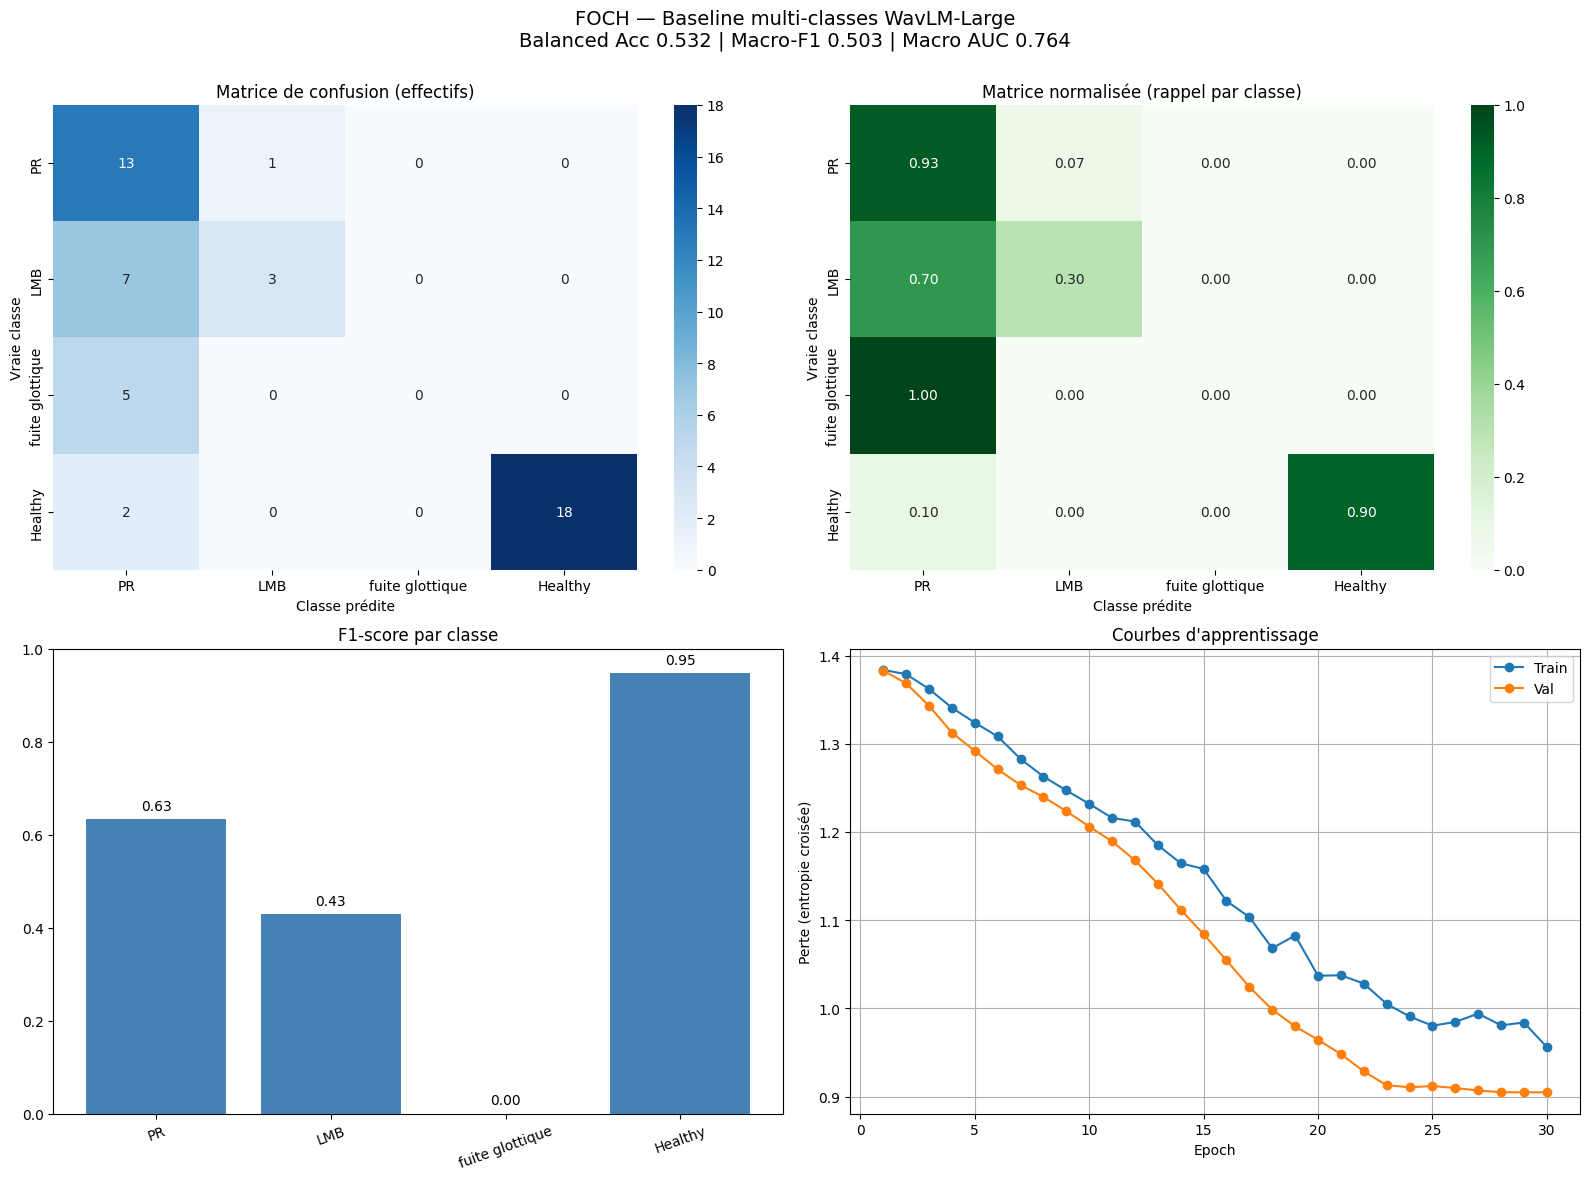


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • wavlm_large_baseline_dashboard.png
  • wavlm_large_baseline_metrics.json
  • wavlm_large_baseline_confusion.csv


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation clinique multi-classes
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    balanced_accuracy_score, f1_score,
)

# Recharge des meilleurs poids avant l'évaluation finale.
model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
print('Inférence sur le jeu de validation...')
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb).logits
        all_probs.extend(F.softmax(logits, dim=1).cpu().numpy())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

# ── Rapport de classification & métriques agrégées ───────────────────────────
labels_idx = np.arange(NUM_LABELS)
print('\n' + classification_report(all_labels, all_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
bal_acc  = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
try:
    macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr',
                              average='macro', labels=labels_idx)
except ValueError:
    macro_auc = float('nan')   # survient si une classe est absente de la validation
print(f'Balanced accuracy : {bal_acc:.4f} | Macro-F1 : {macro_f1:.4f} | '
      f'Macro AUC (OvR) : {macro_auc:.4f}')

# ── Tableau de bord 2×2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'FOCH — Baseline multi-classes WavLM-Large\n'
             f'Balanced Acc {bal_acc:.3f} | Macro-F1 {macro_f1:.3f} | Macro AUC {macro_auc:.3f}',
             fontsize=14)

cm = confusion_matrix(all_labels, all_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion (effectifs)')
axes[0, 0].set_ylabel('Vraie classe'); axes[0, 0].set_xlabel('Classe prédite')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0, 1], vmin=0, vmax=1,
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 1].set_title('Matrice normalisée (rappel par classe)')
axes[0, 1].set_ylabel('Vraie classe'); axes[0, 1].set_xlabel('Classe prédite')

f1_per = f1_score(all_labels, all_preds, average=None, labels=labels_idx, zero_division=0)
axes[1, 0].bar(CLASSES, f1_per, color='steelblue')
axes[1, 0].set_title('F1-score par classe'); axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=20)
for i, v in enumerate(f1_per):
    axes[1, 0].text(i, v + 0.02, f'{v:.2f}', ha='center')

axes[1, 1].plot(range(1, len(train_loss_hist) + 1), train_loss_hist, 'o-', label='Train')
axes[1, 1].plot(range(1, len(val_loss_hist) + 1),   val_loss_hist,   'o-', label='Val')
axes[1, 1].set_title('Courbes d\'apprentissage')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Perte (entropie croisée)')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout(); plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts d'évaluation ────────────────────────────────────
report_dict = classification_report(all_labels, all_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':          RUN_NAME,
    'balanced_accuracy': bal_acc,
    'macro_f1':          macro_f1,
    'macro_auc_ovr':     macro_auc,
    'per_class':         report_dict,
    'classes':           CLASSES,
    'n_train':           int(len(train_df)),
    'n_val':             int(len(val_df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')

## 9. Synthèse et prochaines étapes

Ce notebook établit un **modèle de référence (*baseline*) multi-classes** pour la classification des pathologies laryngées (`PR`, `LMB`, `fuite glottique`, `Healthy`) à partir de WavLM-Large, **sans augmentation de données**.

**Choix méthodologiques clés :**
- Déséquilibre traité par **sous-échantillonnage du groupe contrôle** (~100 enregistrements sains), pour un problème de classification réellement représentatif — et non par pondération de la perte.
- **Pas de fuite patient** grâce au découpage stratifié *et* groupé par `Last_Name`.
- Évaluation centrée sur des métriques **robustes au déséquilibre résiduel** (balanced accuracy, macro-F1, macro AUC), plus informatives que l'accuracy brute.

**Pistes d'amélioration ultérieures :**
1. **Augmentation de données** (bruit, *pitch/time shift*, SpecAugment) — objet du prochain notebook.
2. **Dégel progressif** des couches supérieures du transformer (*progressive unfreezing*).
3. **Validation croisée** sur les 5 plis de `StratifiedGroupKFold` pour des intervalles de confiance.
4. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.
5. **Sensibilité au sous-échantillonnage** — rejouer avec plusieurs tirages aléatoires du groupe sain (`N_HEALTHY`) pour vérifier la stabilité des résultats.

> ⚠️ **Rappel d'exécution** — les cellules sont à exécuter **dans l'ordre** (1 → 8). L'entraînement (Cellule 7) requiert un GPU CUDA ; comptez plusieurs minutes selon la convergence et l'*early stopping*.